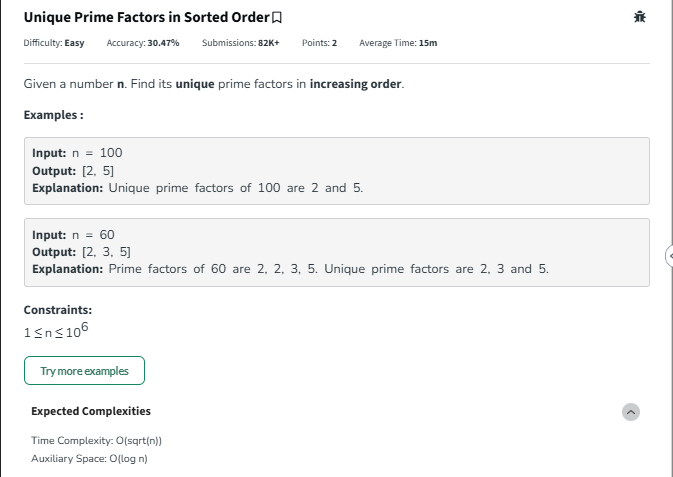

In [10]:
# Optimized 1 (using faster isprime() TC: O(n)

def prime(n):

    if n == 1:
        return False
    if n == 2 or n == 3:
        return True
    if n % 2 == 0 or n % 3 == 0:
        return False

    i = 5
    while i * i <= n:
        if n % i == 0 or n % (i + 2) == 0:
            return False
        i += 6

    return True

def prime_fac():
    n = int(input("plz enter a number "))

    for i in range(2, n + 1):
        
        if prime(i) and n % i == 0:
            print(i)
            while n % i == 0:
                
                n = n // i

    if n > 1:
        print(n)
prime_fac()

2
5


| Scenario | Better Approach | Reason |
|----------|----------------|--------|
| Single query | **Trial Division** | No precomputation cost |
| 2-20 queries | **Trial Division** | Precomputation overhead dominates |
| 20+ queries | **SPF Sieve** | Amortized cost becomes O(log n) per query |
| 1000+ queries | **SPF Sieve** | Dramatically faster (orders of magnitude) |

In [ ]:
# Optimized approach 2: Trial Division (discarding the use of isprime()) TC: O(sqrt(n)):

class Solution:
    def primeFac(self, n):
        # code here
        ans = []
        
        i = 2
        while i * i <= n:
            
            if n % i == 0:
                ans.append(i)
            
            while n % i == 0:
                n = n // i
                # print(n, i, ans)
                
            i += 1
        if n > 1:
            ans.append(n)
            
        return ans

In [ ]:
# Optimized approach 3: (using smallest prime factor (spf)): 

class Solution:
    # Class-level variable to store SPF array
    spf = []
    MAX_N = 1000001  # Adjust based on problem constraints (usually 10^5 or 10^6)

    def __init__(self):
        # Compute SPF only once when the class is first instantiated
        if not Solution.spf:
            Solution.spf = list(range(Solution.MAX_N))
            for i in range(2, int(Solution.MAX_N**0.5) + 1):
                if Solution.spf[i] == i:  # i is prime
                    for j in range(i*i, Solution.MAX_N, i):
                        if Solution.spf[j] == j:
                            Solution.spf[j] = i

    def primeFac(self, n):
        if n <= 1:
            return []
        
        ans = []
        # Use the precomputed SPF array
        while n > 1:
            p = Solution.spf[n]
            # Add only if it's a new unique factor
            if not ans or ans[-1] != p:
                ans.append(p)
            n //= p
        
        return ans   

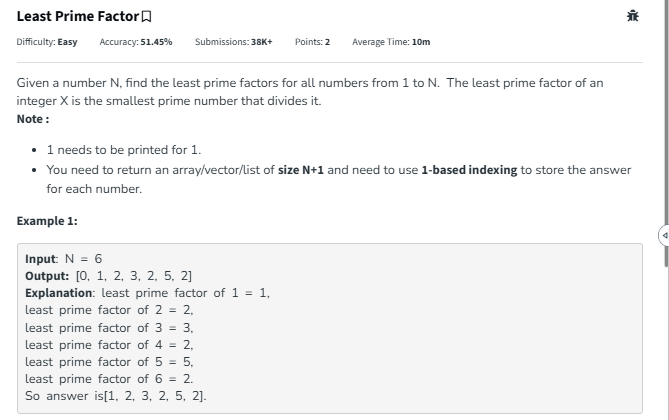
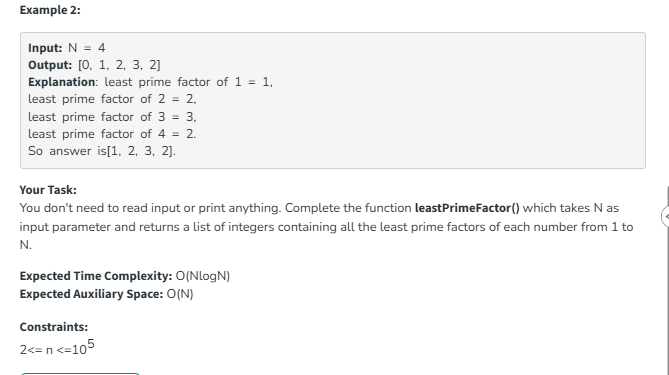

In [ ]:
class Solution:
    # Class-level variable to store SPF array globally
    spf = []
    # Set MAX_N to the maximum possible constraint for n in the problem
    # Usually 10^5 or 10^6 depending on the problem statement. 
    # For problem 5216, check constraints, often 1000 or 10^5.
    MAX_N = 100001 

    def __init__(self):
        # Compute SPF only once when the class is first instantiated
        if not Solution.spf:
            Solution.spf = list(range(Solution.MAX_N))
            # 0 and 1 handling
            Solution.spf[0] = 0
            Solution.spf[1] = 1
            
            # Sieve of Eratosthenes to populate SPF
            for i in range(2, int(Solution.MAX_N**0.5) + 1):
                if Solution.spf[i] == i:  # i is prime
                    for j in range(i*i, Solution.MAX_N, i):
                        if Solution.spf[j] == j:  # Mark only if not already marked
                            Solution.spf[j] = i

    def leastPrimeFactor(self, n):
        """
        Returns a list where index i contains the least prime factor of i.
        Range: 0 to n (inclusive).
        """
        # Since spf is precomputed globally up to MAX_N,
        # we simply return the slice from 0 to n+1.
        # This operation is O(n) for slicing, but the heavy Sieve work was done once.
        return Solution.spf[:n+1]   

HomeWork

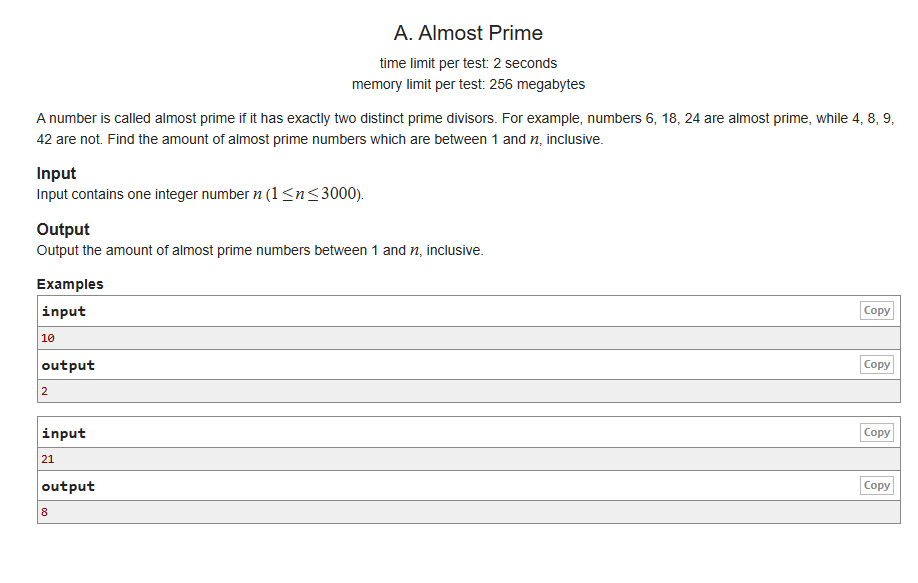

In [ ]:
class Solution:
    mx = 3005
    spf = []
    def __init__(self):
        if not Solution.spf:
            Solution.spf = [i for i in range(Solution.mx)]
            Solution.spf[1] = 1
            for i in range(2, int(Solution.mx ** 0.5) + 1):
                for j in range(i * i, Solution.mx, i):
                    if Solution.spf[j] == j:
                        Solution.spf[j] = i
        # print(Solution.spf)
 
        self.compute(Solution.spf)
 
    def compute(self, spf):
        n = int(input())
        count = 0
        
        if n > 5:
            for i in range(6, n + 1):
                num = i
                temp = []
                while num > 1:
                    p = Solution.spf[num]
                    if not temp or temp[-1] != p:
                        temp.append(p)
                    num //= p
 
                if len(temp) == 2:
                    count += 1
 
        print(count)
            
Solution()

TypeError: 'float' object cannot be interpreted as an integer